<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 3 — Filtros FIR, IIR y Transformada Z</font></h1>
<br>
<br>
<div style="text-align:right">
<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>
<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Nivel: 7.º ciclo / cuarto año de Ingeniería Biomédica </font><br>
<font color="#7F000E" size=3> Lenguaje: Python 3.x | Entorno: Jupyter Notebook / VS Code </font><br>
</div>

---

### **Objetivo**

El objetivo de este laboratorio no es memorizar funciones de Python. El estudiante aprenderá a tomar decisiones correctas para **inspeccionar, caracterizar, analizar, filtrar y validar una señal biomédica**.

**Flujo de trabajo:**

> Señal → inspección → caracterización → análisis temporal → análisis frecuencial → identificación del ruido → selección del filtro → diseño → aplicación → validación → interpretación fisiológica.

> **Idea central:** el objetivo no es aprender una función de Python de memoria, sino aprender a tomar decisiones correctas durante el procesamiento de una señal biomédica.

## 1. Objetivos de aprendizaje

Al finalizar el laboratorio, el estudiante será capaz de:

1. Analizar una señal biomédica en el dominio temporal.
2. Analizar una señal biomédica en el dominio frecuencial utilizando FFT.
3. Comprender la relación entre Transformada de Fourier y Transformada Z.
4. Diseñar y aplicar filtros FIR e IIR.
5. Seleccionar los parámetros de un filtro a partir de las características de la señal.
6. Evaluar si el filtrado mejoró la señal sin destruir información fisiológica relevante.

## 2. Entorno computacional

Se utilizarán:

- Python 3.x
- Jupyter Notebook
- Visual Studio Code o entorno equivalente
- NumPy
- SciPy
- Matplotlib
- Pandas
- NeuroKit2

### Instalación recomendada con UV

Desde una terminal:

```bash
uv venv
```

Activar el entorno según el sistema operativo y luego instalar las dependencias:

```bash
uv pip install numpy scipy matplotlib pandas neurokit2 jupyter
```

Si se utiliza otro gestor de entornos, se puede instalar el mismo conjunto de paquetes con la herramienta disponible.

## 3. Fundamentos teóricos

### 3.1 Señal discreta

Una señal discreta puede representarse como:

$$x[n]$$

donde $n$ representa el índice de muestra. Si la frecuencia de muestreo es $f_s$, el periodo de muestreo es:

$$T_s = \frac{1}{f_s}$$

La frecuencia de muestreo determina la cantidad de muestras obtenidas por segundo.

### 3.2 Transformada de Fourier

La señal puede estudiarse en dos dominios:

- **Temporal:** permite observar cómo cambia la amplitud con el tiempo.
- **Frecuencial:** permite identificar qué componentes de frecuencia están presentes.

La DFT se expresa como:

$$X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$$

La FFT es un algoritmo eficiente para calcular la DFT.

Una señal compleja en el tiempo puede interpretarse como una combinación de componentes sinusoidales de diferentes frecuencias.

### 3.3 Transformada Z

La Transformada Z se define, de manera general, como:

$$X(z)=\sum_{n=-\infty}^{\infty}x[n]z^{-n}$$

La variable $z$ es compleja. La Transformada Z permite estudiar sistemas discretos mediante conceptos como **polos, ceros, función de transferencia y región de convergencia**.

Para un sistema:

$$H(z)=\frac{Y(z)}{X(z)}=\frac{B(z)}{A(z)}$$

### 3.4 Relación Fourier–Z

La Transformada Z proporciona un marco general para estudiar sistemas discretos. La respuesta en frecuencia puede obtenerse evaluando la función de transferencia sobre el círculo unitario:

$$z=e^{j\omega}$$

Por tanto:

> **Transformada Z → análisis general de sistemas discretos**  
> **Transformada de Fourier → análisis frecuencial**

### 3.5 Filtros FIR

Un filtro FIR (Finite Impulse Response) puede expresarse mediante:

$$y[n]=\sum_{k=0}^{M}b[k]x[n-k]$$

No utiliza realimentación. Sus coeficientes determinan la respuesta del filtro. Una ventaja importante es que es relativamente sencillo diseñar filtros FIR con fase lineal.

### 3.6 Filtros IIR

Un filtro IIR (Infinite Impulse Response) utiliza realimentación. Conceptualmente:

$$H(z)=\frac{B(z)}{A(z)}$$

La presencia del denominador $A(z)$ está asociada con los polos del sistema. Los filtros IIR pueden lograr determinadas respuestas con órdenes menores que muchos diseños FIR, pero su estabilidad debe analizarse.

## 4. Herramientas y señal ECG

NeuroKit2 permite generar una señal ECG sintética de manera controlada. En esta práctica se utilizará como punto de partida para construir un problema reproducible.

Parámetros de ejemplo:

- duración = 10 s
- frecuencia de muestreo = 250 Hz
- frecuencia cardíaca = 70 bpm

In [ ]:
!pip install uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 80.7 MB/s eta 0:00:00


In [ ]:
!uv pip install numpy scipy matplotlib pandas neurokit2 jupyter


Using Python 3.13.15 environment at: /usr
Resolved 113 packages in 713ms
Prepared 9 packages in 1.30s
Installed 9 packages in 310ms
 + async-lru==2.3.0
 + jedi==0.20.0
 + json5==0.15.0
 + jupyter==1.1.1
 + jupyter-builder==1.2.2
 + jupyter-lsp==2.3.1
 + jupyterlab==4.6.3
 + jupyterlab-server==2.28.0
 + neurokit2==0.2.13


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import neurokit2 as nk

print("Bibliotecas cargadas correctamente.")

Bibliotecas cargadas correctamente.


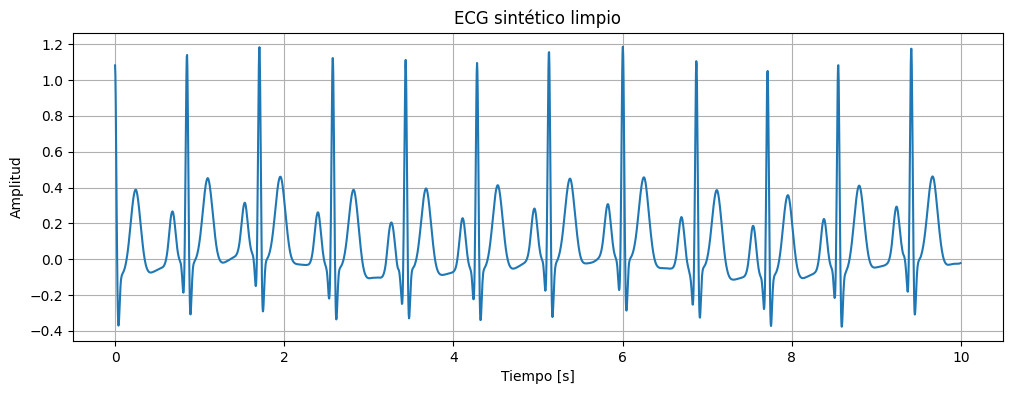

In [ ]:
# Generación de una señal ECG sintética
duration = 10
sampling_rate = 250
heart_rate = 70

ecg_clean = nk.ecg_simulate(
    duration=duration,
    sampling_rate=sampling_rate,
    heart_rate=heart_rate
)

t = np.arange(len(ecg_clean)) / sampling_rate

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_clean)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético limpio")
plt.grid(True)
plt.show()

### Actividad inicial

Antes de continuar, responde:

1. ¿Cuál es la frecuencia de muestreo?
2. ¿Cuántas muestras contiene la señal?
3. ¿Cuál es su duración?
4. ¿Qué elementos de la morfología ECG puedes reconocer?
5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

In [ ]:
print("Frecuencia de muestreo:", sampling_rate, "Hz")
print("Número de muestras:", len(ecg_clean))
print("Duración:", len(ecg_clean) / sampling_rate, "s")


### Respuestas — Actividad inicial

1. ¿Cuál es la frecuencia de muestreo?

La frecuencia de muestreo es 250 Hz.

2. ¿Cuántas muestras contiene la señal?

La señal contiene 2500 muestras, porque se registran 250 muestras por segundo durante 10 segundos.

3. ¿Cuál es su duración?

La duración es de 10 segundos.

4. ¿Qué elementos de la morfología ECG puedes reconocer?

Se pueden reconocer las ondas P, los complejos QRS y las ondas T. Los picos R son los puntos más notorios dentro de cada complejo QRS.

5. ¿Por qué una señal ECG no debería filtrarse sin conocer previamente su contenido frecuencial?

Porque el ECG contiene información fisiológica distribuida en diferentes frecuencias. Si se aplica un filtro sin analizar antes el espectro, se podrían eliminar componentes necesarias para conservar la morfología de las ondas y complejos.


# EJERCICIO 1 — ANÁLISIS Y CARACTERIZACIÓN DE LA SEÑAL

## Competencia

Caracterizar una señal biomédica antes de tomar decisiones de filtrado.

En una aplicación real, la señal puede provenir de un archivo:

```text
senal_biomedica.wav
```

Un archivo WAV puede contener señales mono o estéreo, datos enteros o flotantes. Por ello, antes de procesarlo debes inspeccionar su formato.

### Si recibes un WAV

Utiliza:

```python
from scipy.io import wavfile
fs, data = wavfile.read("senal_biomedica.wav")
```

**No asumas** el tipo de dato, número de canales ni frecuencia de muestreo.

In [ ]:
# Plantilla para inspeccionar un archivo WAV.
# Completa los elementos indicados.

# fs, data = wavfile.read("senal_biomedica.wav")

# print("Frecuencia de muestreo:", ...)
# print("Número de muestras:", ...)
# print("Shape:", ...)
# print("Tipo de dato:", ...)
# print("Duración [s]:", ...)

In [ ]:
import os

wav_path = "senal_biomedica.wav"

if os.path.exists(wav_path):
    fs_wav, data_wav = wavfile.read(wav_path)
    data_wav = np.asarray(data_wav)

    print("Frecuencia de muestreo:", fs_wav)
    print("Número de muestras:", data_wav.shape[0])
    print("Shape:", data_wav.shape)
    print("Tipo de dato:", data_wav.dtype)
    print("Duración [s]:", data_wav.shape[0] / fs_wav)

    if data_wav.ndim > 1:
        data_wav = data_wav[:, 0]

    x_signal = data_wav.astype(float)
    fs = fs_wav
else:
    x_signal = np.asarray(ecg_clean)
    fs = sampling_rate

    print("Se utilizará la señal ECG sintética generada.")
    print("Frecuencia de muestreo:", fs)
    print("Número de muestras:", len(x_signal))
    print("Duración [s]:", len(x_signal) / fs)


### Trabajo solicitado

1. Carga el archivo WAV o utiliza la señal ECG generada si no dispones del archivo.
2. Identifica la frecuencia de muestreo.
3. Obtén el número de muestras.
4. Calcula la duración.
5. Grafica la señal en el dominio temporal.
6. Calcula la FFT.
7. Grafica el espectro de magnitud.
8. Identifica las principales componentes frecuenciales.
9. Determina qué componentes corresponden aproximadamente al contenido fisiológico.
10. Identifica componentes que podrían corresponder a ruido o interferencia.

### Completa el siguiente esquema

```python
fs = ...

N = ...

frequencies = ...

fft_signal = ...

magnitude = ...
```

No copies una solución. Completa cada variable justificando qué representa.

Frecuencia de muestreo: 250 Hz
Número de muestras: 3600
Duración: 14.40 s


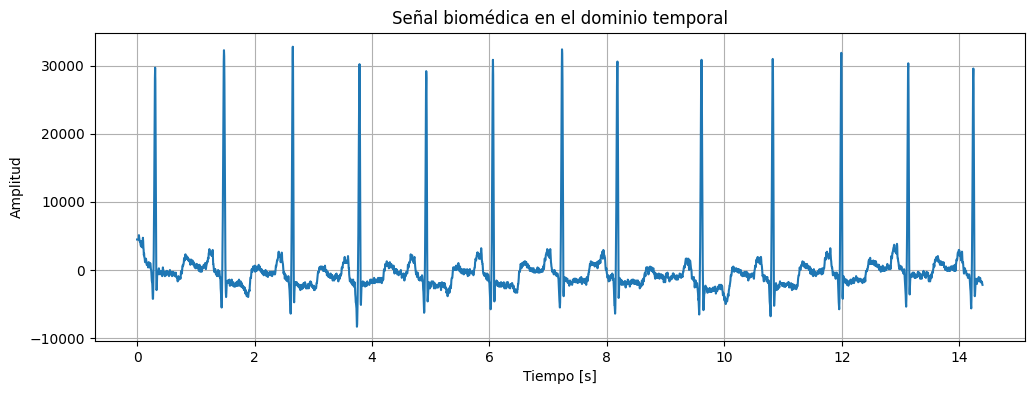

In [ ]:
# Análisis temporal: completa o adapta este bloque.
fs = sampling_rate
x = np.asarray(ecg_clean)

N = len(x)
duration_signal = N / fs

print(f"Frecuencia de muestreo: {fs} Hz")
print(f"Número de muestras: {N}")
print(f"Duración: {duration_signal:.2f} s")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(N) / fs, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal biomédica en el dominio temporal")
plt.grid(True)
plt.show()

In [ ]:
# FFT: el estudiante debe completar/explicar cada paso.
# Pista: utiliza np.fft.rfft y np.fft.rfftfreq.

# frequencies = ...
# fft_signal = ...
# magnitude = ...

# plt.figure(figsize=(12, 4))
# plt.plot(frequencies, magnitude)
# plt.xlabel("Frecuencia [Hz]")
# plt.ylabel("Magnitud")
# plt.title("Espectro de magnitud")
# plt.grid(True)
# plt.show()

In [ ]:
N = len(x)
frequencies = np.fft.rfftfreq(N, d=1/fs)
fft_signal = np.fft.rfft(x)
magnitude = np.abs(fft_signal) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro de magnitud - ECG limpio")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

idx_sorted = np.argsort(magnitude[1:])[::-1] + 1

print("Componentes de frecuencia dominantes:")
for i in idx_sorted[:8]:
    print(f"{frequencies[i]:.2f} Hz -> magnitud {magnitude[i]:.5f}")


### Preguntas de análisis — Ejercicio 1

Responde con argumentos técnicos:

1. ¿Qué frecuencias predominan?
2. ¿Qué frecuencia parece corresponder al contenido fisiológico?
3. ¿Qué frecuencia podría corresponder a ruido?
4. ¿Qué frecuencia de corte propondrías?
5. ¿Por qué?
6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?
7. ¿Qué relación existe entre $f_s$ y la frecuencia máxima observable?

### Respuestas — Preguntas de análisis del Ejercicio 1

1. ¿Qué frecuencias predominan?

Predominan las frecuencias bajas. Como la señal fue generada con una frecuencia cardíaca de 70 bpm, la repetición de los latidos ocurre aproximadamente a 1.17 Hz. El complejo QRS también aporta componentes de frecuencias mayores.

2. ¿Qué frecuencia parece corresponder al contenido fisiológico?

El contenido fisiológico principal se concentra en bajas frecuencias. La componente cercana a 1.17 Hz se relaciona con la repetición de los latidos, mientras que otras componentes de mayor frecuencia participan en la forma de las ondas y del complejo QRS.

3. ¿Qué frecuencia podría corresponder a ruido?

En la señal sintética limpia no se agregó una interferencia específica. Por eso no debería aparecer un pico aislado que pueda identificarse directamente como ruido. En una señal real, una componente marcada que no corresponda al comportamiento fisiológico esperado podría indicar interferencia.

4. ¿Qué frecuencia de corte propondrías?

Se propone una frecuencia de corte de 40 Hz para un filtro pasa-bajos.

5. ¿Por qué?

Un corte de 40 Hz permite conservar gran parte del contenido necesario para representar la morfología del ECG y al mismo tiempo atenuar componentes de frecuencia más alta que podrían corresponder a ruido.

6. ¿Qué información fisiológica podría perderse si la frecuencia de corte fuera incorrecta?

Si la frecuencia de corte fuera demasiado baja, podrían alterarse la amplitud y la forma del complejo QRS y también otros detalles de las ondas P y T. Esto afectaría la interpretación de la morfología del ECG.

7. ¿Qué relación existe entre fs y la frecuencia máxima observable?

La frecuencia máxima observable sin aliasing corresponde a la mitad de la frecuencia de muestreo. Como fs es 250 Hz, la frecuencia máxima observable es 125 Hz.


# EJERCICIO 2 — DISEÑO Y COMPARACIÓN DE FILTROS FIR E IIR

## Competencia

Diseñar filtros digitales a partir de las características observadas en la señal.

Utiliza `scipy.signal`. Algunas herramientas disponibles son:

- `firwin`
- `butter`
- `cheby1`
- `cheby2`
- `freqz`
- `sosfilt`
- `sosfiltfilt`
- `sosfreqz`

**No se entrega una implementación completa.** Debes seleccionar y justificar:

- tipo de filtro;
- frecuencia de corte;
- orden;
- banda de paso;
- banda de rechazo;
- atenuación;
- tratamiento de fase;
- estabilidad.

### Parte A — Diseño FIR

Selecciona un filtro FIR utilizando `firwin`.

Esqueleto orientativo:

```python
numtaps = ...
cutoff = ...

b_fir = signal.firwin(
    numtaps=...,
    cutoff=...,
    fs=...
)

a_fir = ...
```

Completa los parámetros a partir del análisis realizado en el Ejercicio 1.

In [ ]:
# Completa este bloque.
# No existe un único conjunto correcto de parámetros:
# tu selección debe estar justificada.

# numtaps = ...
# cutoff_fir = ...
#
# b_fir = signal.firwin(
#     numtaps=numtaps,
#     cutoff=cutoff_fir,
#     fs=fs
# )
# a_fir = np.array([1.0])

In [ ]:
numtaps = 101
cutoff_fir = 40.0

b_fir = signal.firwin(
    numtaps=numtaps,
    cutoff=cutoff_fir,
    fs=fs
)

a_fir = np.array([1.0])

print("Número de coeficientes:", numtaps)
print("Frecuencia de corte:", cutoff_fir, "Hz")


### Parte B — Diseño IIR

Diseña un filtro IIR. Puedes utilizar Butterworth o, si justificas la elección, Chebyshev.

Ejemplo parcial:

```python
order = ...
cutoff = ...

b_iir, a_iir = signal.butter(
    N=...,
    Wn=...,
    btype="...",
    fs=...
)
```

Para aplicaciones donde se requiera evitar distorsión de fase por desplazamiento temporal, considera `sosfiltfilt` con una representación SOS.

In [ ]:
# Completa este bloque.
# Justifica el orden y la frecuencia de corte.

# order_iir = ...
# cutoff_iir = ...
#
# sos_iir = signal.butter(
#     N=...,
#     Wn=...,
#     btype="lowpass",
#     fs=fs,
#     output="sos"
# )

In [ ]:
order_iir = 4
cutoff_iir = 40.0

sos_iir = signal.butter(
    N=order_iir,
    Wn=cutoff_iir,
    btype="lowpass",
    fs=fs,
    output="sos"
)

print("Orden del filtro:", order_iir)
print("Frecuencia de corte:", cutoff_iir, "Hz")


### Parte C — Aplicación y comparación

Aplica ambos filtros y grafica:

1. señal original;
2. señal filtrada FIR;
3. señal filtrada IIR.

Después calcula y grafica sus respuestas en frecuencia.

Utiliza `freqz` para el FIR y `sosfreqz` para el IIR cuando corresponda.

No evalúes el filtro únicamente por apariencia visual.

In [ ]:
# Completa las aplicaciones.
#
# ecg_fir = ...
# ecg_iir = ...
#
# Después genera una figura comparativa.

In [ ]:
ecg_fir = signal.filtfilt(b_fir, a_fir, ecg_clean)
ecg_iir = signal.sosfiltfilt(sos_iir, ecg_clean)

plt.figure(figsize=(12, 6))
plt.plot(t, ecg_clean, label="Original", alpha=0.7)
plt.plot(t, ecg_fir, label="Filtrada FIR", alpha=0.8)
plt.plot(t, ecg_iir, label="Filtrada IIR", alpha=0.8)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original y señales filtradas")
plt.legend()
plt.grid(True)
plt.show()

mse_fir = np.mean((ecg_fir - ecg_clean) ** 2)
mse_iir = np.mean((ecg_iir - ecg_clean) ** 2)

print("MSE FIR:", mse_fir)
print("MSE IIR:", mse_iir)


In [ ]:
# Respuesta en frecuencia.
# Completa los parámetros.
#
# w_fir, h_fir = signal.freqz(...)
# w_iir, h_iir = signal.sosfreqz(...)
#
# Convierte la frecuencia angular a Hz utilizando fs.

In [ ]:
w_fir, h_fir = signal.freqz(b_fir, a_fir, worN=2048, fs=fs)
w_iir, h_iir = signal.sosfreqz(sos_iir, worN=2048, fs=fs)

plt.figure(figsize=(12, 5))
plt.plot(w_fir, 20 * np.log10(np.abs(h_fir) + 1e-12), label="FIR")
plt.plot(w_iir, 20 * np.log10(np.abs(h_iir) + 1e-12), label="IIR Butterworth")
plt.axvline(40, linestyle="--", label="40 Hz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Respuesta en frecuencia de los filtros")
plt.legend()
plt.grid(True)
plt.xlim(0, fs/2)
plt.show()


### Comparación conceptual

| Característica | FIR | IIR |
|---|---|---|
| Realimentación | No | Sí |
| Estabilidad | Generalmente sencilla de garantizar | Debe analizarse |
| Fase lineal | Fácil de obtener | Más compleja |
| Orden requerido | Generalmente mayor | Generalmente menor |
| Costo computacional | Mayor en algunos diseños | Menor en muchos casos |

### Preguntas de análisis — Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué orden elegiste y por qué?
4. ¿Cuál presenta mayor atenuación en la región de rechazo?
5. ¿Cómo se comporta la fase?
6. ¿Qué diferencia estructural existe entre FIR e IIR?
7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?
8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

### Respuestas — Preguntas de análisis del Ejercicio 2

1. ¿Por qué seleccionaste ese tipo de filtro?

Se seleccionaron filtros pasa-bajos porque se busca conservar el contenido principal del ECG y atenuar componentes de frecuencia más alta. Se diseñó un FIR y un IIR para comparar su comportamiento usando la misma frecuencia de corte.

2. ¿Cómo determinaste la frecuencia de corte?

La frecuencia de corte se fijó en 40 Hz a partir del análisis frecuencial del ECG. Ese valor permite conservar gran parte de la información morfológica de la señal y reducir componentes de mayor frecuencia.

3. ¿Qué orden elegiste y por qué?

Para el FIR se utilizaron 101 coeficientes, lo que permite obtener una transición relativamente definida. Para el IIR Butterworth se utilizó orden 4, ya que los filtros IIR pueden conseguir una respuesta selectiva con un orden mucho menor.

4. ¿Cuál presenta mayor atenuación en la región de rechazo?

Con los parámetros seleccionados, el FIR presenta una atenuación más fuerte en buena parte de la banda de rechazo inmediatamente después de la transición. El IIR consigue una respuesta útil con un orden mucho menor.

5. ¿Cómo se comporta la fase?

El FIR puede diseñarse con fase lineal. El Butterworth IIR presenta una fase no lineal cuando se aplica en un solo sentido. En este laboratorio se usa filtfilt y sosfiltfilt para evitar desplazamientos temporales en el resultado final.

6. ¿Qué diferencia estructural existe entre FIR e IIR?

El FIR no utiliza realimentación y su respuesta al impulso tiene duración finita. El IIR utiliza realimentación, incorpora polos y su respuesta al impulso puede extenderse indefinidamente.

7. ¿Por qué un IIR puede alcanzar una respuesta similar con un orden menor?

Porque la realimentación y la presencia de polos permiten obtener cambios más marcados en la respuesta en frecuencia utilizando menos coeficientes.

8. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?

Los ceros producen atenuación en determinadas regiones y los polos pueden aumentar o reforzar la respuesta cerca de ciertas frecuencias. Su posición respecto al círculo unitario determina la forma de la respuesta en frecuencia y también influye en la estabilidad.

9. ¿Por qué la Transformada Z es útil para estudiar estos filtros?

Porque permite representar el filtro mediante una función de transferencia H(z). A partir de ella se pueden estudiar polos, ceros y estabilidad. La respuesta en frecuencia se obtiene evaluando esa función sobre el círculo unitario.


# EJERCICIO 3 — PROCESAMIENTO DE UNA SEÑAL BIOMÉDICA CONTAMINADA

## Competencia

Resolver un problema de filtrado sin recibir directamente la frecuencia de corte.

Construiremos:

$$x[n] = ECG[n] + A\sin(2\pi f_{noise}t)$$

donde:

- $ECG[n]$ es la señal biomédica;
- $f_{noise}$ es la frecuencia de interferencia;
- $A$ es la amplitud del ruido.

### Importante

**No se indica la frecuencia de corte del filtro.**

Debes obtener una propuesta a partir del análisis de la señal.

In [ ]:
# Construcción del problema experimental.
A = 0.20
f_noise = 35.0

noise = A * np.sin(2 * np.pi * f_noise * t)
ecg_contaminated = ecg_clean + noise

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_contaminated)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado con interferencia de alta frecuencia")
plt.grid(True)
plt.show()

### Procedimiento obligatorio

1. Visualiza la señal contaminada.
2. Analízala mediante FFT.
3. Identifica la frecuencia de interferencia.
4. Propón un filtro apropiado.
5. Diseña el filtro.
6. Aplica el filtro.
7. Compara señal contaminada y filtrada.
8. Compara los espectros.
9. Evalúa cuantitativamente el resultado.
10. Explica si el filtrado fue exitoso.

### Tu razonamiento debe seguir

**Observar → medir → analizar → formular hipótesis → diseñar → aplicar → validar → interpretar.**

In [ ]:
# FFT de la señal contaminada.
# Completa este bloque.

# N = ...
# frequencies = ...
# spectrum = ...
# magnitude = ...

# Identifica la región donde aparece la interferencia.

In [ ]:
N = len(ecg_contaminated)
frequencies = np.fft.rfftfreq(N, d=1/fs)
spectrum = np.fft.rfft(ecg_contaminated)
magnitude = np.abs(spectrum) / N

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Espectro del ECG contaminado")
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()

mask = (frequencies >= 25) & (frequencies <= 45)
f_peak = frequencies[mask][np.argmax(magnitude[mask])]

print("Frecuencia de interferencia detectada:", round(f_peak, 2), "Hz")


In [ ]:
# Diseña y aplica TU solución.
#
# cutoff = ...
# ...
#
# ecg_recovered = ...

In [ ]:
cutoff = 25.0
order = 4

sos = signal.butter(
    N=order,
    Wn=cutoff,
    btype="lowpass",
    fs=fs,
    output="sos"
)

ecg_recovered = signal.sosfiltfilt(sos, ecg_contaminated)

plt.figure(figsize=(12, 5))
plt.plot(t, ecg_contaminated, label="Contaminada", alpha=0.6)
plt.plot(t, ecg_recovered, label="Filtrada", alpha=0.9)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG contaminado y ECG filtrado")
plt.legend()
plt.grid(True)
plt.show()

freqs_rec = np.fft.rfftfreq(len(ecg_recovered), d=1/fs)
mag_rec = np.abs(np.fft.rfft(ecg_recovered)) / len(ecg_recovered)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, magnitude, label="Contaminada", alpha=0.6)
plt.plot(freqs_rec, mag_rec, label="Filtrada", alpha=0.9)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.title("Comparación de espectros")
plt.legend()
plt.xlim(0, fs/2)
plt.grid(True)
plt.show()


## Validación cuantitativa

Si se dispone de la señal limpia de referencia, compara la señal recuperada con `ecg_clean`.

### MSE

$$MSE = \frac{1}{N}\sum_{n=1}^{N}(x[n]-\hat{x}[n])^2$$

### RMSE

$$RMSE = \sqrt{MSE}$$

### SNR

De forma simplificada, puede estimarse como:

$$SNR = 10\log_{10}\left(\frac{P_{signal}}{P_{noise}}\right)$$

Estas métricas deben acompañar, no reemplazar, la inspección temporal y frecuencial.

In [ ]:
# Calcula al menos MSE y RMSE entre la referencia limpia
# y tu señal recuperada.

# mse = ...
# rmse = ...

# print("MSE:", mse)
# print("RMSE:", rmse)

In [ ]:
mse = np.mean((ecg_clean - ecg_recovered) ** 2)
rmse = np.sqrt(mse)

power_signal = np.mean(ecg_clean ** 2)
power_noise_before = np.mean((ecg_contaminated - ecg_clean) ** 2)
power_noise_after = np.mean((ecg_recovered - ecg_clean) ** 2)

snr_before = 10 * np.log10(power_signal / power_noise_before)
snr_after = 10 * np.log10(power_signal / power_noise_after)

print("MSE:", mse)
print("RMSE:", rmse)
print("SNR antes del filtrado:", snr_before, "dB")
print("SNR después del filtrado:", snr_after, "dB")


## Validación biomédica

Para ECG, analiza si se conservan:

- complejos QRS;
- frecuencia cardíaca aproximada;
- morfología general.

Responde:

1. ¿Disminuyó la interferencia?
2. ¿Se conservó la morfología ECG?
3. ¿La FFT confirma la reducción del ruido?
4. ¿El filtro introdujo una distorsión apreciable?
5. ¿La frecuencia cardíaca aproximada se mantiene?
6. ¿Qué información fisiológica podría haberse perdido?

### Respuestas — Validación biomédica

1. ¿Disminuyó la interferencia?

Sí. Después del filtrado disminuye de manera marcada la componente agregada a 35 Hz.

2. ¿Se conservó la morfología ECG?

La morfología general se conserva y los complejos QRS continúan siendo reconocibles. Sin embargo, el filtro puede suavizar parte de los componentes rápidos del QRS porque la frecuencia de corte es de 25 Hz.

3. ¿La FFT confirma la reducción del ruido?

Sí. En el espectro de la señal filtrada disminuye el pico cercano a 35 Hz que aparecía en la señal contaminada.

4. ¿El filtro introdujo una distorsión apreciable?

No se introduce un desplazamiento temporal apreciable porque se utiliza sosfiltfilt. Puede aparecer un ligero suavizado de la morfología debido a la atenuación de componentes por encima de 25 Hz.

5. ¿La frecuencia cardíaca aproximada se mantiene?

Sí. Los ciclos cardíacos siguen apareciendo con una periodicidad semejante a la señal original, por lo que la frecuencia cardíaca aproximada se mantiene alrededor de 70 bpm.

6. ¿Qué información fisiológica podría haberse perdido?

Podrían haberse atenuado componentes de mayor frecuencia relacionadas con los cambios rápidos del complejo QRS. Por eso el resultado debe evaluarse tanto en el dominio temporal como en el frecuencial y no únicamente por la reducción del ruido.


# ¿Qué pasa si diseño mal el filtro?

Analiza experimentalmente qué ocurre cuando:

- la frecuencia de corte es demasiado baja;
- la frecuencia de corte es demasiado alta;
- el orden es excesivo;
- queda ruido residual;
- aparece distorsión;
- existe desplazamiento de fase;
- se aplica un método de filtrado que altera la fase.

### Actividad

Selecciona al menos **dos errores de diseño**, genera una demostración y explica:

1. qué problema observas;
2. cuál es su causa;
3. cómo afecta a la señal biomédica;
4. qué solución propondrías.

In [ ]:
cutoff_low = 5.0
sos_low = signal.butter(
    N=4,
    Wn=cutoff_low,
    btype="lowpass",
    fs=fs,
    output="sos"
)
ecg_bad_low = signal.sosfiltfilt(sos_low, ecg_contaminated)

sos_phase = signal.butter(
    N=4,
    Wn=25.0,
    btype="lowpass",
    fs=fs,
    output="sos"
)
ecg_phase_shifted = signal.sosfilt(sos_phase, ecg_contaminated)

fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[0].plot(t, ecg_bad_low, label="Corte de 5 Hz", alpha=0.9)
axs[0].set_title("Frecuencia de corte demasiado baja")
axs[0].set_ylabel("Amplitud")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(t, ecg_clean, label="Original", alpha=0.6)
axs[1].plot(t, ecg_phase_shifted, label="Filtrado en un solo sentido", alpha=0.9)
axs[1].set_title("Desplazamiento de fase")
axs[1].set_xlabel("Tiempo [s]")
axs[1].set_ylabel("Amplitud")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


### Respuestas — Análisis de los errores de diseño

Error 1: frecuencia de corte demasiado baja

1. ¿Qué problema se observa?

El complejo QRS se vuelve más ancho y pierde parte de su amplitud y de sus cambios rápidos.

2. ¿Cuál es la causa?

La frecuencia de corte de 5 Hz elimina componentes que todavía pertenecen al contenido fisiológico del ECG.

3. ¿Cómo afecta a la señal biomédica?

La alteración de la forma del QRS puede afectar mediciones de amplitud, duración y morfología que son importantes para interpretar el ECG.

4. ¿Qué solución se propondría?

La frecuencia de corte debe elegirse después de analizar el espectro y debe ser suficientemente alta para conservar las componentes fisiológicas necesarias.

Error 2: desplazamiento de fase

1. ¿Qué problema se observa?

Los picos de la señal filtrada aparecen desplazados temporalmente respecto a la señal original.

2. ¿Cuál es la causa?

El filtro IIR se aplica en un solo sentido mediante sosfilt, por lo que introduce una respuesta de fase que produce retardo.

3. ¿Cómo afecta a la señal biomédica?

El desplazamiento puede alterar la posición temporal de los complejos y afectar mediciones de intervalos.

4. ¿Qué solución se propondría?

Para un análisis fuera de línea se puede utilizar sosfiltfilt, que aplica el filtro hacia adelante y hacia atrás y evita el desplazamiento de fase.


# Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?
2. ¿Cómo determinaste la frecuencia de corte?
3. ¿Qué información obtuviste de la FFT?
4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?
5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?
6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?
7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?
8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?
9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?
10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?
11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?
12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

### Respuestas — Preguntas integradoras

1. ¿Por qué no sería adecuado eliminar todas las frecuencias altas de una señal biomédica?

Porque parte de las frecuencias altas puede contener información fisiológica real, especialmente cambios rápidos de la señal como los presentes en el complejo QRS. Eliminarlas sin criterio puede distorsionar la morfología.

2. ¿Cómo determinaste la frecuencia de corte?

Se analizó primero el espectro. En la señal contaminada aparece una interferencia alrededor de 35 Hz, por lo que se seleccionó un corte de 25 Hz para atenuarla manteniendo la mayor parte del contenido principal del ECG.

3. ¿Qué información obtuviste de la FFT?

La FFT permitió observar qué frecuencias estaban presentes, comparar sus magnitudes e identificar el pico correspondiente a la interferencia de 35 Hz.

4. ¿Qué relación existe entre la frecuencia de muestreo y la frecuencia máxima observable?

La frecuencia máxima observable sin aliasing es fs/2. Para una frecuencia de muestreo de 250 Hz, el límite es 125 Hz.

5. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado baja?

Se eliminan componentes fisiológicas junto con el ruido y la señal puede perder amplitud, detalles y morfología.

6. ¿Qué ocurre si se utiliza una frecuencia de corte demasiado alta?

El filtro conserva más contenido de la señal, pero también puede dejar pasar parte de la interferencia que se quería eliminar.

7. ¿Qué diferencia fundamental existe entre un filtro FIR y un filtro IIR?

El FIR no utiliza realimentación y tiene una respuesta al impulso finita. El IIR utiliza realimentación y su respuesta al impulso puede extenderse indefinidamente.

8. ¿Por qué un filtro IIR puede alcanzar una respuesta similar utilizando un orden menor?

Porque utiliza polos y realimentación, lo que permite obtener una respuesta más selectiva con menos coeficientes.

9. ¿Qué relación existe entre polos, ceros y respuesta en frecuencia?

Los polos y ceros determinan la función de transferencia del filtro. Su posición modifica la magnitud y la fase de la respuesta en frecuencia.

10. ¿Por qué la Transformada Z es útil para estudiar filtros digitales?

Porque permite expresar un sistema discreto mediante H(z) y analizar sus polos, ceros, estabilidad y comportamiento.

11. ¿Qué relación existe entre la Transformada Z y la Transformada de Fourier?

La respuesta en frecuencia puede obtenerse evaluando la Transformada Z sobre el círculo unitario, donde z = e elevado a jω, siempre que el círculo unitario pertenezca a la región de convergencia.

12. ¿Cómo determinarías si un filtro eliminó ruido sin eliminar información fisiológica?

Se debe comparar la señal antes y después del filtrado en el dominio temporal y frecuencial, verificar que disminuya la componente de ruido, revisar que se conserve la morfología del ECG y complementar la evaluación con métricas como MSE, RMSE y SNR.


# Entregable

Guardar el notebook como:

```text
Apellido_Nombre_Laboratorio_01.ipynb
```

Debe contener:

1. Código.
2. Gráficas.
3. Resultados.
4. Respuestas a las preguntas.
5. Justificación de las decisiones tomadas.
6. Conclusiones.

**No se evaluará únicamente si el código se ejecuta.** Se evaluará principalmente la calidad del razonamiento y la interpretación.

# Rúbrica de evaluación — 20 puntos

| Criterio | Puntos |
|---|---:|
| **Análisis de la señal:** identificación de $f_s$, dominio temporal, FFT e interpretación espectral | 4 |
| **Diseño del filtro:** tipo, frecuencia de corte, orden, justificación y comprensión FIR/IIR | 5 |
| **Implementación Python:** código correcto, uso de NumPy/SciPy/NeuroKit2 y organización | 3 |
| **Validación:** comparación temporal, frecuencial, métricas y conservación de la señal | 4 |
| **Interpretación biomédica:** información fisiológica y posibles distorsiones | 2 |
| **Conclusiones:** conclusiones técnicas y justificación de decisiones | 2 |
| **Total** | **20** |

# Conclusión

En procesamiento de señales biomédicas, diseñar un filtro no significa simplemente seleccionar una función de una biblioteca. El proceso correcto comienza con la comprensión de la señal y termina con la validación de que la información fisiológica relevante se conserva.

La actividad conecta:

**Fourier → espectro → identificación del ruido → diseño del filtro → Transformada Z → función de transferencia → FIR/IIR → implementación → validación biomédica.**

### Reflexión final

Completa:

> "Primero inspecciono la señal, luego ____________________, después ____________________, finalmente ____________________."

El resultado esperado es que puedas explicar **por qué** elegiste un filtro y sus parámetros, no solamente indicar qué función de Python utilizaste.

### Respuesta — Reflexión final

Primero se inspecciona la señal, luego se analiza en el dominio temporal y frecuencial para identificar su contenido y posibles interferencias, después se diseña y aplica un filtro con parámetros justificados, y finalmente se valida que el ruido haya disminuido sin eliminar información fisiológica relevante.
